In [292]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [293]:
s_1 = pd.read_csv("strategy_performance_ETH_train.csv", index_col=0)
s_2 = pd.read_csv("strategy_performance_DOGE_train.csv", index_col=0)
s_3 = pd.read_csv("strategy_performance_DOGE_0_train.csv", index_col=0)
# s_4 = pd.read_csv("strategy_performance_BTC_train.csv", index_col=0)


In [294]:

btc = pd.read_csv(
    "/Users/lizeyu/Desktop/Quant-on-Crypto/strategies/mmpair-strategy/mmpair-strategy/1m_klines_raw/BTCUSDT_klines_1m.csv"
)
# 时间戳统一到微秒
btc["Close Time"] = btc["Close Time"].apply(
    lambda x: x * 1000 + 999 if x < 2000000000000 else x
)
btc["Open Time"] = btc["Open Time"].apply(
    lambda x: x * 1000 if x < 2000000000000 else x
)

# 将时间戳转换为 datetime 格式
btc["Close Time"] = pd.to_datetime(btc["Close Time"], unit="us")
btc["Open Time"] = pd.to_datetime(btc["Open Time"], unit="us")

# 设置索引
btc.set_index("Close Time", inplace=True)
btc.sort_index(inplace=True)

In [295]:
total = pd.concat([s_1, s_2, s_3], axis=1)
total.columns = ['ETH', 'DOGE', 'DOGE_0']

In [296]:
total.index = pd.to_datetime(total.index)
total = total.dropna()


# 在绘图前先检查数据
print("Data shape:", total.shape)
print("Data info:")
print(total.info())
print("\nFirst few rows:")
print(total.head())
print("\nLast few rows:")
print(total.tail())

# 检查是否有 NaN 或 inf 值
print("\nNaN values:")
print(total.isnull().sum())
print("\nInf values:")
print(np.isinf(total).sum())

Data shape: (519841, 3)
Data info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 519841 entries, 2024-06-05 23:59:59.999999 to 2025-06-01 23:59:59.999999
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ETH     519841 non-null  float64
 1   DOGE    519841 non-null  float64
 2   DOGE_0  519841 non-null  float64
dtypes: float64(3)
memory usage: 15.9 MB
None

First few rows:
                               ETH    DOGE       DOGE_0
Close Time                                             
2024-06-05 23:59:59.999999  5000.0  5000.0  4998.946553
2024-06-06 00:00:59.999999  5000.0  5000.0  4998.974184
2024-06-06 00:01:59.999999  5000.0  5000.0  4998.925062
2024-06-06 00:02:59.999999  5000.0  5000.0  4998.931203
2024-06-06 00:03:59.999999  5000.0  5000.0  4998.915852

Last few rows:
                                    ETH         DOGE       DOGE_0
Close Time                                                       
2025-06-01 23:

In [297]:
btc_filtered = btc.loc[total.index]
btc_close = btc_filtered["Close"].values

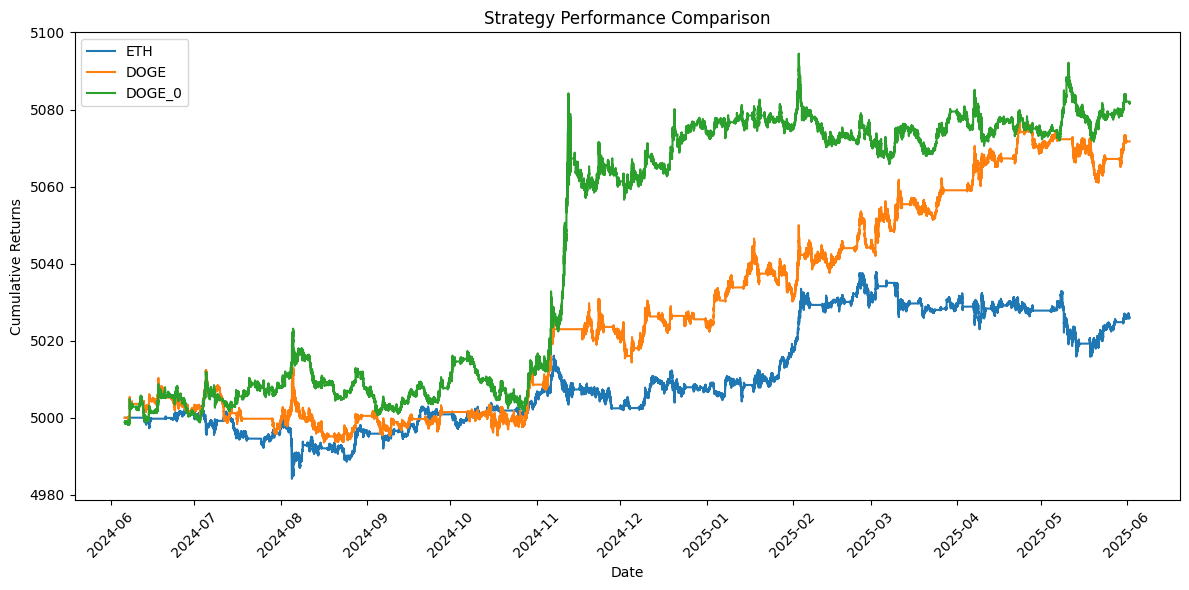

In [298]:
# 对数据进行采样以提高绘图性能
# 每100个数据点取一个点进行绘图
total_sampled = total#[::60]  # 采样，减少数据点

plt.figure(figsize=(12, 6))
for column in total_sampled.columns:
    plt.plot(total_sampled.index, total_sampled[column], label=column)  
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.title('Strategy Performance Comparison')
plt.legend()

# 简略显示x轴的几种方法：
import matplotlib.dates as mdates

# 方法1：只显示月份
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))


plt.xticks(rotation=45)  # 旋转日期标签
plt.tight_layout()
plt.show()

In [299]:
total

,ETH,DOGE,DOGE_0
Close Time,,,
2024-06-05 23:59:59.999999,5000.000000,5000.000000,4998.946553
2024-06-06 00:00:59.999999,5000.000000,5000.000000,4998.974184
2024-06-06 00:01:59.999999,5000.000000,5000.000000,4998.925062
2024-06-06 00:02:59.999999,5000.000000,5000.000000,4998.931203
2024-06-06 00:03:59.999999,5000.000000,5000.000000,4998.915852
...,...,...,...
2025-06-01 23:55:59.999999,5026.017088,5071.712709,5081.592598
2025-06-01 23:56:59.999999,5026.017088,5071.712709,5081.605475
2025-06-01 23:57:59.999999,5026.017088,5071.712709,5081.626079


In [314]:
# 按3天为间隔求每列均值
total_aggre_mean = total.resample('3D').mean()
btc_close_aggre_mean = pd.Series(btc_close, index=total.index).resample('3D').mean()

In [315]:
total_aggre_diff = total_aggre_mean.diff()
btc_close_aggre_diff = btc_close_aggre_mean.diff()

In [316]:
total_aggre_diff.dropna(inplace=True)
btc_close_aggre_diff.dropna(inplace=True)

In [317]:
total_aggre_diff

,ETH,DOGE,DOGE_0
Close Time,,,
2024-06-08,0.000000,3.235255,3.619275
2024-06-11,-0.311073,-0.378003,-0.616392
2024-06-14,-0.317242,1.072437,-0.872418
2024-06-17,0.369446,2.011947,3.466084
2024-06-20,0.136937,-0.940820,1.154335
...,...,...,...
2025-05-19,-0.179855,-5.747578,-2.898977
2025-05-22,3.342290,1.243816,4.097755
2025-05-25,1.488395,1.557373,0.247847


In [318]:
btc_close_aggre_diff

Close Time
2024-06-08   -1344.809780
2024-06-11   -1793.168847
2024-06-14   -1300.113845
2024-06-17    -866.009745
2024-06-20    -924.978877
                 ...     
2025-05-19    2058.626965
2025-05-22    4010.230380
2025-05-25    -908.148463
2025-05-28   -1870.022127
2025-05-31   -2667.570921
Freq: 3D, Length: 120, dtype: float64

In [319]:
# 计算每列的前5%分位数
thresholds = total_aggre_diff.quantile(0.0)

# 将小于等于前5%分位数的值替换为0
total_aggre_diff = total_aggre_diff.apply(lambda x: x.where(x > thresholds[x.name], 0))

In [320]:
n = len(total_aggre_diff.columns)

In [348]:
a = 0
b = 0

def loss(total_aggre_diff, a, b):
  if a+b>1:
    return float('inf')
  else:
    c = 1 - a - b
    weights = np.array([a, b, c])
    weighted_diff = total_aggre_diff.values @ weights
    minus_count = np.sum(weighted_diff < 0)

    corr = np.corrcoef(weighted_diff, btc_close_aggre_diff.values)[0, 1]

    return_std = np.std(weighted_diff)
    return_mean = np.mean(weighted_diff)


    loss_value = -return_mean/return_std*(1-abs(corr))
    return loss_value
def gradient_descent(total_aggre_diff, learning_rate=0.01, epochs=1000):
    a, b = 0.33, 0.33  # 初始权重
    for epoch in range(epochs):
        grad_a = (loss(total_aggre_diff, a + 1e-5, b) - loss(total_aggre_diff, a - 1e-5, b)) / (2e-5)
        grad_b = (loss(total_aggre_diff, a, b + 1e-5) - loss(total_aggre_diff, a, b - 1e-5)) / (2e-5)
        a -= learning_rate * grad_a
        b -= learning_rate * grad_b
        # 投影回可行域
        if a < 0: a = 0
        if b < 0: b = 0
        if a + b > 1:
            tot = a + b
            a /= tot
            b /= tot
    return a, b

a_opt, b_opt = gradient_descent(total_aggre_diff, learning_rate=0.1, epochs=5000)
c_opt = 1 - a_opt - b_opt
print(f"Optimal weights: a={a_opt:.4f}, b={b_opt:.4f}, c={c_opt:.4f}")

Optimal weights: a=0.3556, b=0.5392, c=0.1052


In [349]:
weight_opt = np.array([a_opt, b_opt, c_opt])
weight_aver = np.array([1/3, 1/3, 1/3])

weighted_value_opt = total.values @ weight_opt
weighted_value_aver = total.values @ weight_aver

In [368]:
a_opt = 9/18
b_opt = 6/18
c_opt = 3/18
weight_opt = np.array([a_opt, b_opt, c_opt])


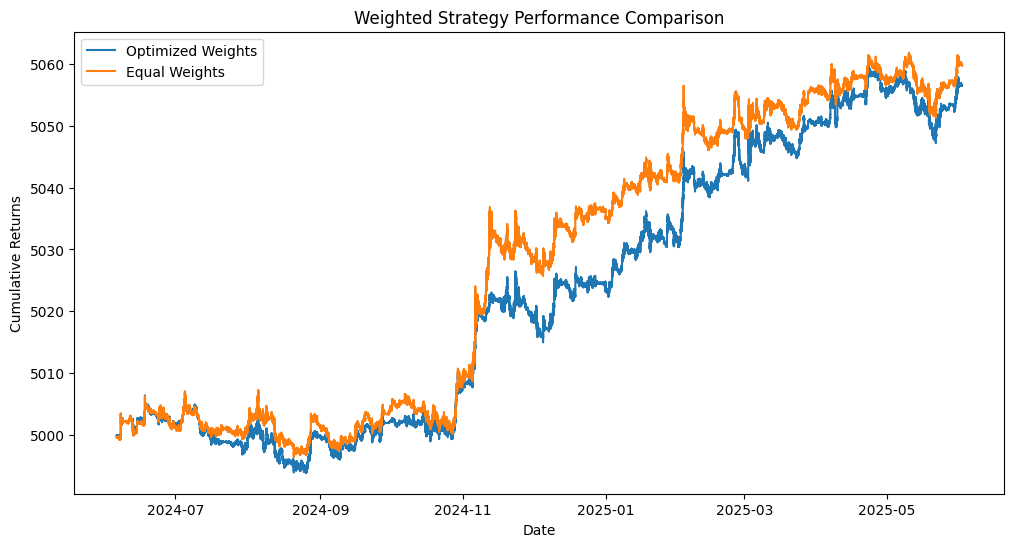

In [369]:
plt.figure(figsize=(12, 6))
plt.plot(total.index, weighted_value_opt, label='Optimized Weights')  
plt.plot(total.index, weighted_value_aver, label='Equal Weights')  
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.title('Weighted Strategy Performance Comparison')
plt.legend()  
plt.show()

In [370]:
corr = np.corrcoef(total_aggre_diff.values @ weight_opt, btc_close_aggre_diff)[0, 1]
corr

np.float64(0.06384201130076987)

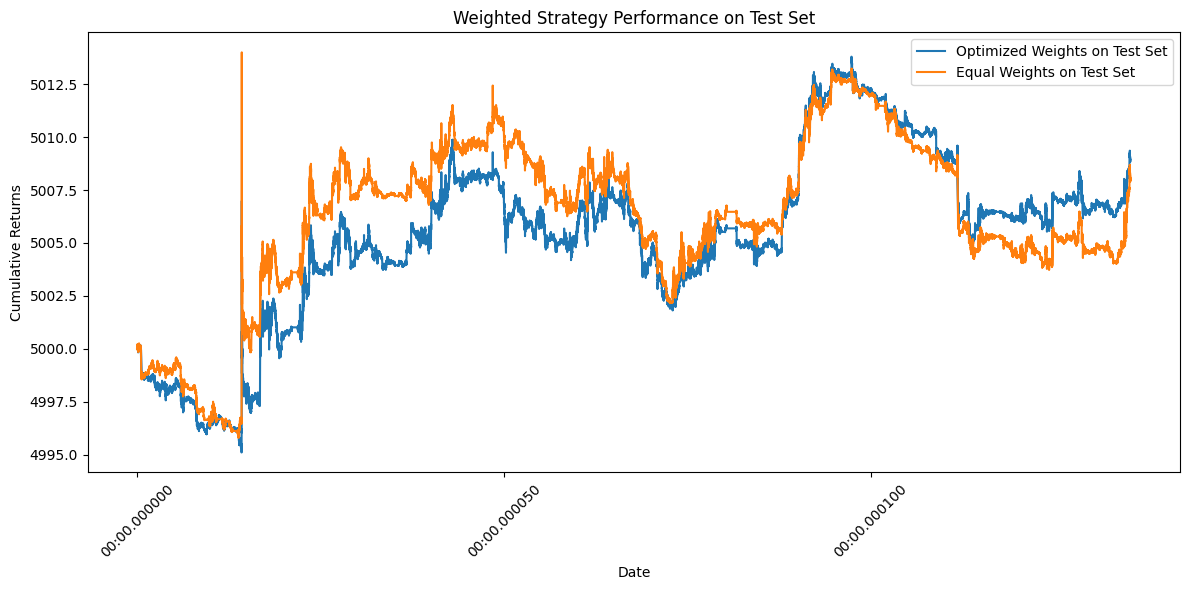

In [371]:
# s_1_t = pd.read_csv("strategy_performance_ETH_test.csv", index_col=0)
# s_2_t = pd.read_csv("strategy_performance_DOGE_test.csv", index_col=0)
# s_3_t = pd.read_csv("strategy_performance_DOGE_0_test.csv", index_col=0)
# s_4_t = pd.read_csv("strategy_performance_BTC_test.csv", index_col=0)
s_1_t = pd.read_csv("/Users/lizeyu/Desktop/Quant-on-Crypto/examples/rev-usds/asset_balance_eth.csv", index_col=0)
s_2_t = pd.read_csv("/Users/lizeyu/Desktop/Quant-on-Crypto/examples/rev-usds/asset_balance_doge.csv", index_col=0)
s_3_t = pd.read_csv("/Users/lizeyu/Desktop/Quant-on-Crypto/examples/rev-usds/asset_balance_doge_0.csv", index_col=0)
# s_4_t = pd.read_csv("/Users/lizeyu/Desktop/Quant-on-Crypto/examples/rev-usds/asset_balance_btc.csv", index_col=0)
for  x in [s_1_t, s_2_t, s_3_t]:
    x.index = x['Time Steps']
    x.drop(columns=['Time Steps'], inplace=True)

total_t = pd.concat([s_1_t, s_2_t, s_3_t], axis=1)
total_t.columns = ['ETH', 'DOGE', 'DOGE_0']
total_t.index = pd.to_datetime(total_t.index)
total_t = total_t.dropna()
total_t_weighted_opt = total_t.values @ weight_opt
total_t_weighted_aver = total_t.values @ weight_aver
plt.figure(figsize=(12, 6))
plt.plot(total_t.index, total_t_weighted_opt, label='Optimized Weights on Test Set')  
plt.plot(total_t.index, total_t_weighted_aver, label='Equal Weights on Test Set')

# # 方法1：只显示月份
# plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
# plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))


plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.title('Weighted Strategy Performance on Test Set')
plt.legend()
plt.xticks(rotation=45)  # 旋转日期标签
plt.tight_layout()
plt.show()
plt.close()


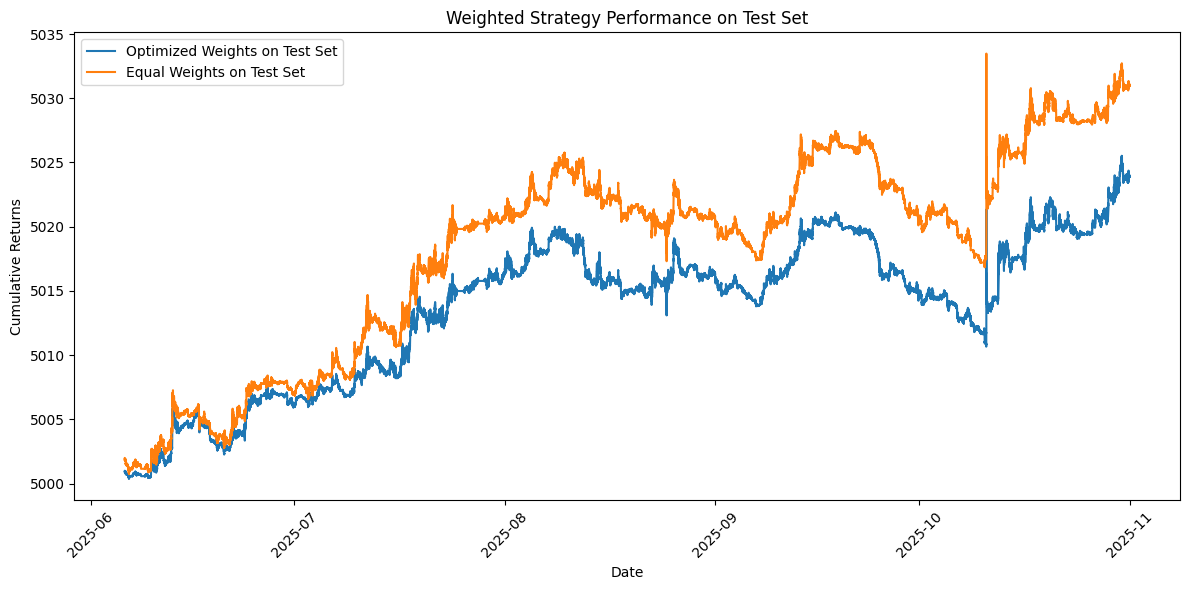

In [372]:
s_1_t = pd.read_csv("strategy_performance_ETH_test.csv", index_col=0)
s_2_t = pd.read_csv("strategy_performance_DOGE_test.csv", index_col=0)
s_3_t = pd.read_csv("strategy_performance_DOGE_0_test.csv", index_col=0)

total_t = pd.concat([s_1_t, s_2_t, s_3_t], axis=1)
total_t.columns = ['ETH', 'DOGE', 'DOGE_0']
total_t.index = pd.to_datetime(total_t.index)
total_t = total_t.dropna()
total_t_weighted_opt = total_t.values @ weight_opt
total_t_weighted_aver = total_t.values @ weight_aver
plt.figure(figsize=(12, 6))
plt.plot(total_t.index, total_t_weighted_opt, label='Optimized Weights on Test Set')  
plt.plot(total_t.index, total_t_weighted_aver, label='Equal Weights on Test Set')

# # 方法1：只显示月份
# plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
# plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))


plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.title('Weighted Strategy Performance on Test Set')
plt.legend()
plt.xticks(rotation=45)  # 旋转日期标签
plt.tight_layout()
plt.show()
plt.close()

In [373]:
weight_opt

array([0.5       , 0.33333333, 0.16666667])